# Estadística descriptiva con Python y Jupyter

## Objetivo

Este notebook presenta un ejemplo completo de **estadística descriptiva** utilizando Python,
Pandas, NumPy, Matplotlib y Seaborn.

Trabajaremos con un conjunto de datos sintético relacionado con personas, incluyendo
variables demográficas, antropométricas, laborales y de hábitos de estudio.

### Conceptos tratados

- Tipos de variables.
- Frecuencias absolutas y relativas.
- Medidas de tendencia central.
- Medidas de dispersión.
- Percentiles y cuartiles.
- Rango intercuartílico.
- Coeficiente de variación.
- Asimetría y curtosis.
- Detección visual de valores atípicos.
- Histogramas.
- Boxplots.
- Gráficos de barras.
- Gráficos de dispersión.
- Matriz de correlaciones.
- Interpretación estadística.

> **Nota:** Los datos son sintéticos y se generan de forma reproducible mediante una semilla fija.

In [2]:
# Instalación opcional desde Jupyter si alguna biblioteca no está disponible:
# %pip install pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


## 1. Carga de los datos

El proyecto incluye un CSV inicial. Para que el notebook sea reproducible,
se utiliza el fichero `datos_estadistica_descriptiva.csv`.

Si se desea utilizar el notebook en otro directorio, basta con colocar el CSV
en la misma carpeta que el notebook.

In [3]:
from pathlib import Path

csv_file = Path("datos_estadistica_descriptiva.csv")

if not csv_file.exists():
    raise FileNotFoundError(
        f"No se encuentra {csv_file}. Coloca el CSV en la misma carpeta que el notebook."
    )

df = pd.read_csv(csv_file)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
display(df.head())

Filas: 120
Columnas: 10


,id,edad,altura_m,peso_kg,imc,empleo,actividad_fisica,horas_estudio_semana,satisfaccion,ingresos_euros
0,1,22,1.61,59.1,22.8,Servicios,Baja,7.1,6,3023
1,2,55,1.80,92.5,28.5,Industria,Moderada,7.6,2,2141
2,3,49,1.53,59.6,25.5,Tecnología,Moderada,10.7,2,1630
3,4,39,1.67,71.1,25.5,Educación,Alta,1.6,6,2263
4,5,38,1.72,84.4,28.5,Educación,Moderada,3.9,2,2982


## 2. Conocer la estructura del conjunto de datos

Antes de calcular estadísticas debemos conocer:

- Número de observaciones.
- Número de variables.
- Tipo de cada variable.
- Posibles valores ausentes.

In [4]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo"))

print("\nInformación general:")
df.info()

print("\nValores ausentes:")
display(df.isna().sum().to_frame("valores_ausentes"))

Dimensiones: (120, 10)

Tipos de datos:


,tipo
id,int64
edad,int64
altura_m,float64
peso_kg,float64
imc,float64
empleo,str
actividad_fisica,str
horas_estudio_semana,float64
satisfaccion,int64
ingresos_euros,int64



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    120 non-null    int64  
 1   edad                  120 non-null    int64  
 2   altura_m              120 non-null    float64
 3   peso_kg               120 non-null    float64
 4   imc                   120 non-null    float64
 5   empleo                120 non-null    str    
 6   actividad_fisica      120 non-null    str    
 7   horas_estudio_semana  120 non-null    float64
 8   satisfaccion          120 non-null    int64  
 9   ingresos_euros        120 non-null    int64  
dtypes: float64(4), int64(4), str(2)
memory usage: 9.5 KB

Valores ausentes:


,valores_ausentes
id,0
edad,0
altura_m,0
peso_kg,0
imc,0
empleo,0
actividad_fisica,0
horas_estudio_semana,0
satisfaccion,0
ingresos_euros,0


## 3. Variables del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | Cuantitativa discreta | Identificador |
| `edad` | Cuantitativa | Edad en años |
| `altura_m` | Cuantitativa continua | Altura en metros |
| `peso_kg` | Cuantitativa continua | Peso en kg |
| `imc` | Cuantitativa continua | Índice de masa corporal |
| `empleo` | Cualitativa nominal | Sector profesional |
| `actividad_fisica` | Cualitativa ordinal | Nivel de actividad |
| `horas_estudio_semana` | Cuantitativa continua | Horas de estudio |
| `satisfaccion` | Cuantitativa ordinal | Escala de 1 a 10 |
| `ingresos_euros` | Cuantitativa continua | Ingresos mensuales |

## 4. Estadística descriptiva básica

In [5]:
variables_numericas = [
    "edad", "altura_m", "peso_kg", "imc",
    "horas_estudio_semana", "satisfaccion", "ingresos_euros"
]

estadistica = df[variables_numericas].describe().T
estadistica["varianza"] = df[variables_numericas].var()
estadistica["asimetria"] = df[variables_numericas].skew()
estadistica["curtosis"] = df[variables_numericas].kurt()

display(estadistica.round(3))

,count,mean,std,min,25%,50%,75%,max,varianza,asimetria,curtosis
edad,120.0,42.442,13.150,18.00,31.000,42.50,54.250,64.00,172.921,-0.189,-1.196
altura_m,120.0,1.688,0.091,1.49,1.618,1.68,1.742,1.99,0.008,0.437,0.299
peso_kg,120.0,70.498,10.566,40.80,64.500,70.25,75.125,102.20,111.639,0.445,0.993
imc,120.0,24.666,2.568,16.80,22.800,24.60,26.300,31.10,6.594,0.025,0.103
horas_estudio_semana,120.0,7.928,3.296,1.00,5.775,7.80,10.100,16.30,10.864,0.042,-0.290
satisfaccion,120.0,5.408,2.909,1.00,3.000,5.00,8.000,10.00,8.462,0.169,-1.177
ingresos_euros,120.0,2309.133,608.262,1000.00,1799.000,2333.50,2727.250,3632.00,369982.234,-0.121,-0.589


## 5. Media, mediana y moda

Las medidas de tendencia central permiten identificar un valor representativo
de una distribución.

- **Media:** suma de los valores dividida entre el número de observaciones.
- **Mediana:** valor central después de ordenar los datos.
- **Moda:** valor o valores que aparecen con mayor frecuencia.

In [6]:
tendencia = pd.DataFrame({
    "media": df[variables_numericas].mean(),
    "mediana": df[variables_numericas].median(),
    "moda": df[variables_numericas].mode().iloc[0]
})

display(tendencia.round(3))

,media,mediana,moda
edad,42.442,42.50,55.00
altura_m,1.688,1.68,1.72
peso_kg,70.498,70.25,65.30
imc,24.666,24.60,24.60
horas_estudio_semana,7.928,7.80,6.90
satisfaccion,5.408,5.00,6.00
ingresos_euros,2309.133,2333.50,1000.00


## 6. Medidas de dispersión

La media por sí sola no describe completamente una distribución.

Calcularemos:

- Rango.
- Varianza.
- Desviación estándar.
- Rango intercuartílico.
- Coeficiente de variación.

El coeficiente de variación se calcula como:

\[
CV = \frac{\sigma}{\bar{x}}\times100
\]

y permite comparar la variabilidad relativa de variables que pueden estar
en escalas diferentes.

In [7]:
dispersion = pd.DataFrame(index=variables_numericas)

dispersion["mínimo"] = df[variables_numericas].min()
dispersion["máximo"] = df[variables_numericas].max()
dispersion["rango"] = dispersion["máximo"] - dispersion["mínimo"]
dispersion["varianza"] = df[variables_numericas].var()
dispersion["desviación_estándar"] = df[variables_numericas].std()
dispersion["Q1"] = df[variables_numericas].quantile(0.25)
dispersion["Q3"] = df[variables_numericas].quantile(0.75)
dispersion["IQR"] = dispersion["Q3"] - dispersion["Q1"]
dispersion["CV_%"] = (
    dispersion["desviación_estándar"] / df[variables_numericas].mean()
) * 100

display(dispersion.round(3))

,mínimo,máximo,rango,varianza,desviación_estándar,Q1,Q3,IQR,CV_%
edad,18.00,64.00,46.0,172.921,13.150,31.000,54.250,23.250,30.984
altura_m,1.49,1.99,0.5,0.008,0.091,1.618,1.742,0.125,5.387
peso_kg,40.80,102.20,61.4,111.639,10.566,64.500,75.125,10.625,14.987
imc,16.80,31.10,14.3,6.594,2.568,22.800,26.300,3.500,10.410
horas_estudio_semana,1.00,16.30,15.3,10.864,3.296,5.775,10.100,4.325,41.577
satisfaccion,1.00,10.00,9.0,8.462,2.909,3.000,8.000,5.000,53.787
ingresos_euros,1000.00,3632.00,2632.0,369982.234,608.262,1799.000,2727.250,928.250,26.342


## 7. Percentiles y cuartiles

Los percentiles dividen los datos ordenados en posiciones relativas.

Los cuartiles más utilizados son:

- Q1 = percentil 25.
- Q2 = percentil 50 = mediana.
- Q3 = percentil 75.

El rango intercuartílico es:

\[
IQR = Q_3-Q_1
\]

In [8]:
percentiles = df[variables_numericas].quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
display(percentiles.round(3))

,edad,altura_m,peso_kg,imc,horas_estudio_semana,satisfaccion,ingresos_euros
0.05,21.95,1.560,54.495,20.795,2.100,1.0,1282.15
0.10,23.90,1.579,58.330,21.570,3.300,2.0,1508.10
0.25,31.00,1.618,64.500,22.800,5.775,3.0,1799.00
0.50,42.50,1.680,70.250,24.600,7.800,5.0,2333.50
0.75,54.25,1.742,75.125,26.300,10.100,8.0,2727.25
0.90,58.10,1.791,84.410,27.960,12.210,10.0,3041.40
0.95,61.05,1.850,87.645,29.110,13.215,10.0,3257.15


## 8. Frecuencias de variables categóricas

Para las variables cualitativas utilizamos frecuencias absolutas y relativas.

In [9]:
for variable in ["empleo", "actividad_fisica"]:
    print(f"\n### {variable}")
    frecuencia = df[variable].value_counts(dropna=False).to_frame("frecuencia")
    frecuencia["porcentaje"] = 100 * frecuencia["frecuencia"] / len(df)
    display(frecuencia.round(2))


### empleo


,frecuencia,porcentaje
empleo,,
Oficina,34,28.33
Servicios,26,21.67
Tecnología,24,20.00
Industria,18,15.00
Educación,18,15.00



### actividad_fisica


,frecuencia,porcentaje
actividad_fisica,,
Moderada,54,45.00
Alta,34,28.33
Baja,32,26.67


## 9. Gráfico de barras

Los gráficos de barras son apropiados para representar variables categóricas.

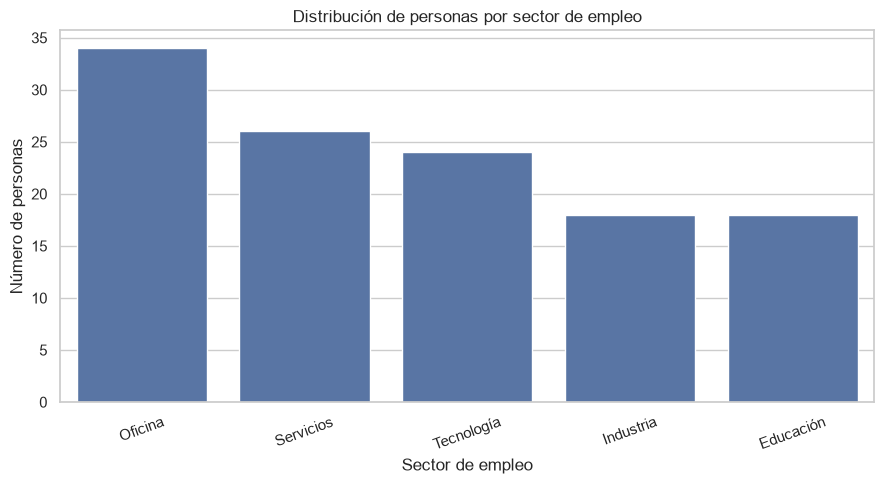

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

orden = df["empleo"].value_counts().index
sns.countplot(
    data=df,
    x="empleo",
    order=orden,
    ax=ax
)

ax.set_title("Distribución de personas por sector de empleo")
ax.set_xlabel("Sector de empleo")
ax.set_ylabel("Número de personas")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. Histograma de la edad

Un histograma permite estudiar la forma de una distribución cuantitativa.

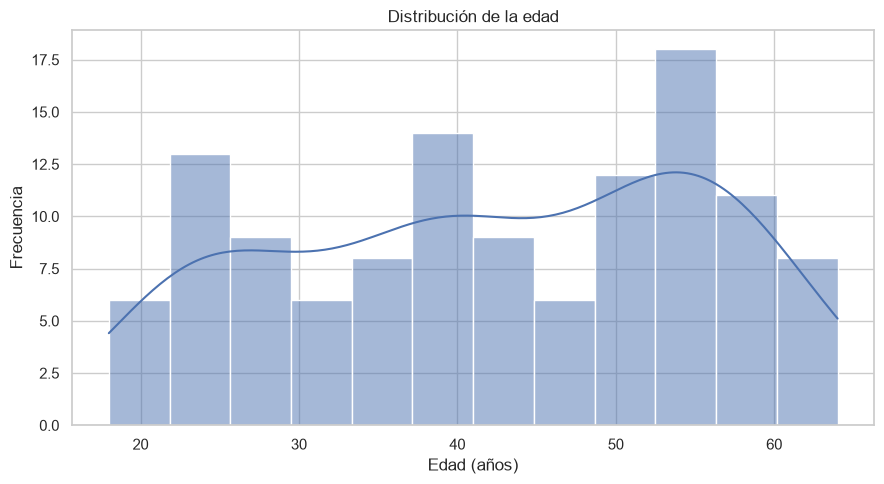

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="edad",
    bins=12,
    kde=True,
    ax=ax
)

ax.set_title("Distribución de la edad")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 11. Histograma del IMC

El mismo procedimiento puede utilizarse para otras variables cuantitativas.

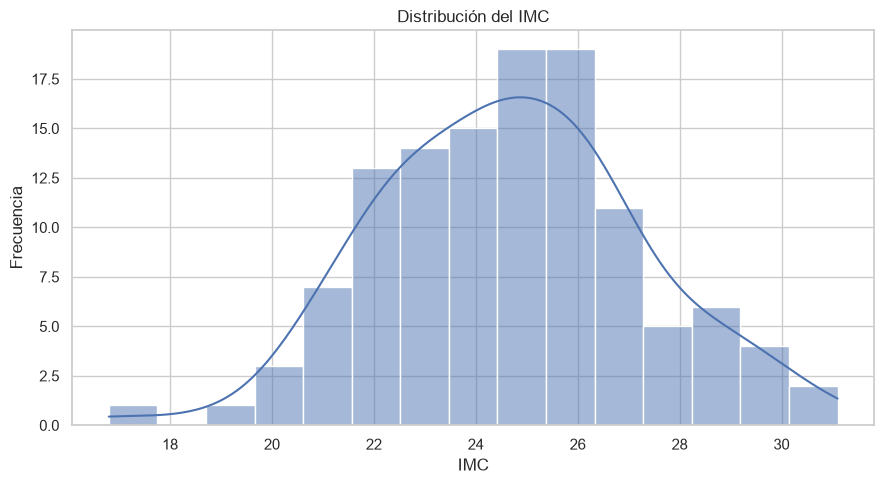

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="imc",
    bins=15,
    kde=True,
    ax=ax
)

ax.set_title("Distribución del IMC")
ax.set_xlabel("IMC")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 12. Boxplot

El boxplot permite visualizar:

- Mediana.
- Primer y tercer cuartil.
- Rango intercuartílico.
- Posibles valores atípicos.

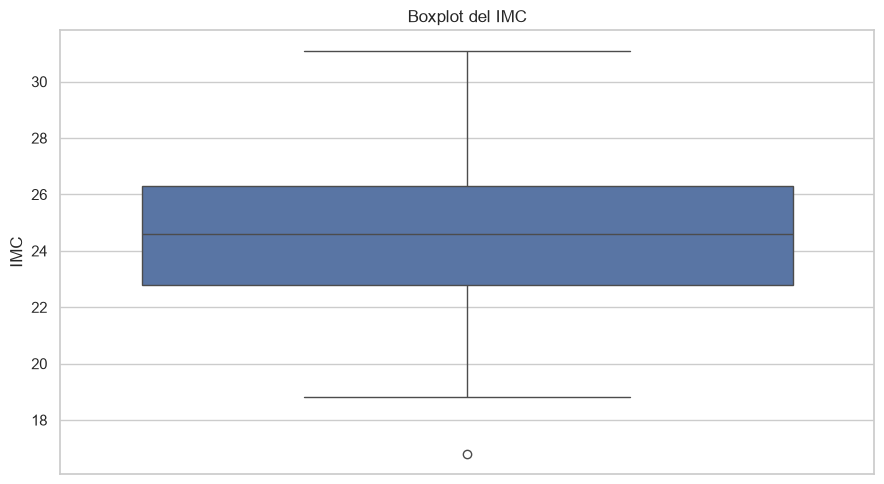

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    y="imc",
    ax=ax
)

ax.set_title("Boxplot del IMC")
ax.set_ylabel("IMC")
plt.tight_layout()
plt.show()

## 13. Comparación de IMC según actividad física

Los boxplots permiten comparar la distribución de una variable cuantitativa
entre diferentes grupos.

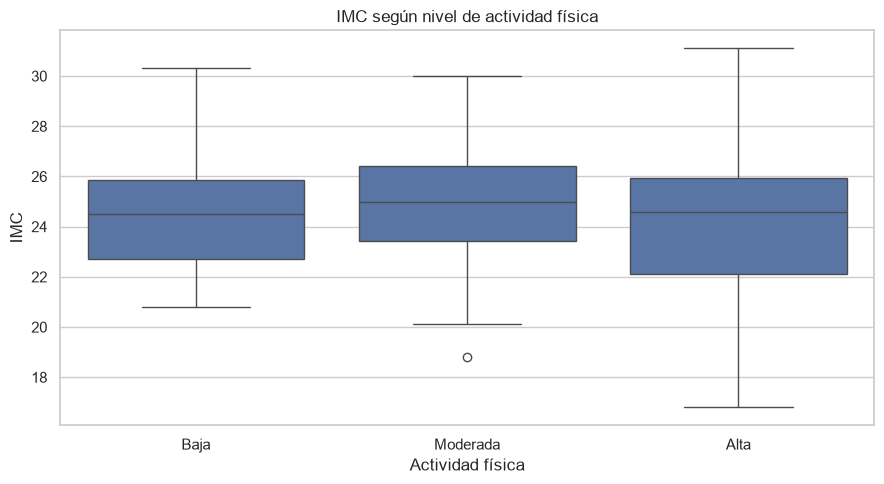

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="actividad_fisica",
    y="imc",
    order=["Baja", "Moderada", "Alta"],
    ax=ax
)

ax.set_title("IMC según nivel de actividad física")
ax.set_xlabel("Actividad física")
ax.set_ylabel("IMC")
plt.tight_layout()
plt.show()

## 14. Relación entre altura y peso

Un gráfico de dispersión permite observar visualmente la relación entre
dos variables cuantitativas.

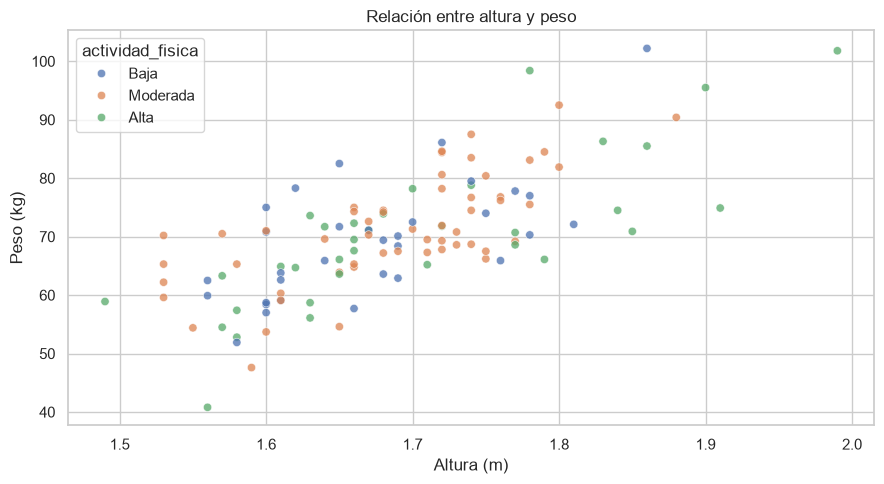

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="altura_m",
    y="peso_kg",
    hue="actividad_fisica",
    alpha=0.75,
    ax=ax
)

ax.set_title("Relación entre altura y peso")
ax.set_xlabel("Altura (m)")
ax.set_ylabel("Peso (kg)")
plt.tight_layout()
plt.show()

## 15. Correlación

El coeficiente de correlación de Pearson mide la intensidad y dirección de
una relación lineal entre dos variables cuantitativas.

Su valor se encuentra entre -1 y 1:

- próximo a 1: relación lineal positiva.
- próximo a -1: relación lineal negativa.
- próximo a 0: poca relación lineal.

In [16]:
correlaciones = df[variables_numericas].corr(method="pearson")
display(correlaciones.round(3))

,edad,altura_m,peso_kg,imc,horas_estudio_semana,satisfaccion,ingresos_euros
edad,1.000,0.044,0.213,0.268,-0.043,-0.101,-0.023
altura_m,0.044,1.000,0.723,-0.007,-0.164,0.032,-0.039
peso_kg,0.213,0.723,1.000,0.680,-0.222,0.069,-0.052
imc,0.268,-0.007,0.680,1.000,-0.150,0.039,-0.060
horas_estudio_semana,-0.043,-0.164,-0.222,-0.150,1.000,-0.032,-0.066
satisfaccion,-0.101,0.032,0.069,0.039,-0.032,1.000,-0.113
ingresos_euros,-0.023,-0.039,-0.052,-0.060,-0.066,-0.113,1.000


## 16. Mapa de calor de correlaciones

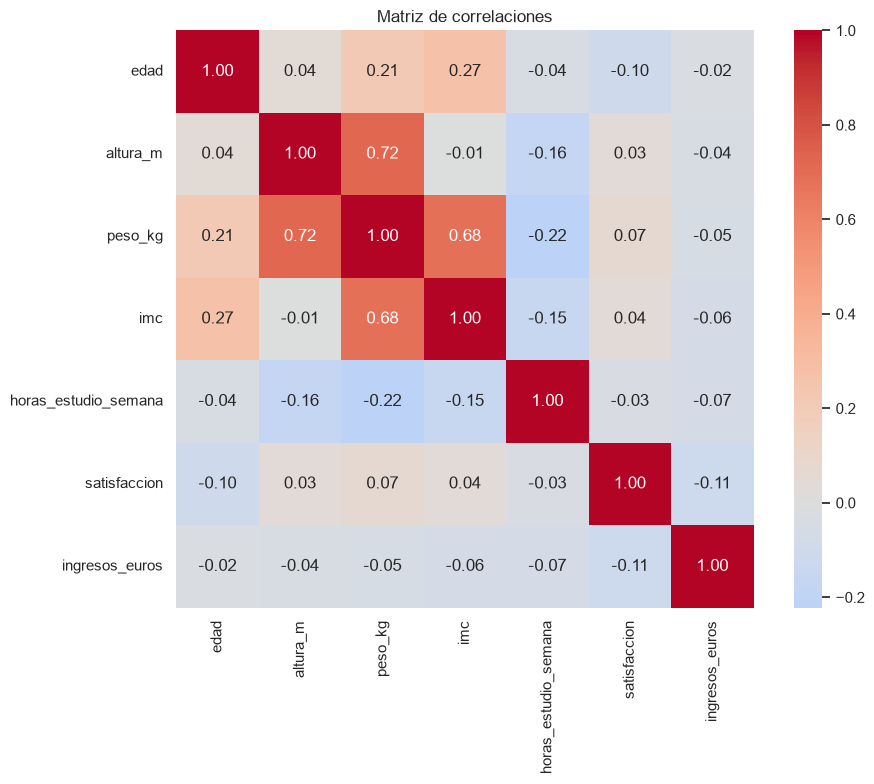

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Matriz de correlaciones")
plt.tight_layout()
plt.show()

## 17. Asimetría y curtosis

La **asimetría** ayuda a identificar si una distribución está desplazada hacia
uno de sus extremos.

La **curtosis** describe el grado de concentración de los datos en torno al
centro y en sus colas respecto a una distribución de referencia.

Estos indicadores deben interpretarse conjuntamente con histogramas y boxplots.

In [18]:
forma = pd.DataFrame({
    "asimetría": df[variables_numericas].skew(),
    "curtosis": df[variables_numericas].kurt()
})

display(forma.round(3))

,asimetría,curtosis
edad,-0.189,-1.196
altura_m,0.437,0.299
peso_kg,0.445,0.993
imc,0.025,0.103
horas_estudio_semana,0.042,-0.290
satisfaccion,0.169,-1.177
ingresos_euros,-0.121,-0.589


## 18. Detección de posibles valores atípicos mediante IQR

Una regla habitual identifica como posibles valores atípicos aquellos que se
encuentran fuera del intervalo:

\[
[Q_1-1.5IQR,\; Q_3+1.5IQR]
\]

Esto no significa que todos los valores detectados sean errores: pueden ser
observaciones reales que requieren interpretación.

In [19]:
def detectar_outliers_iqr(dataframe, variable):
    q1 = dataframe[variable].quantile(0.25)
    q3 = dataframe[variable].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara = (
        (dataframe[variable] < limite_inferior) |
        (dataframe[variable] > limite_superior)
    )

    return dataframe[mascara], limite_inferior, limite_superior

for variable in ["edad", "peso_kg", "imc", "ingresos_euros"]:
    outliers, li, ls = detectar_outliers_iqr(df, variable)

    print(f"{variable}:")
    print(f"  Límite inferior: {li:.2f}")
    print(f"  Límite superior: {ls:.2f}")
    print(f"  Posibles outliers: {len(outliers)}")
    print()

edad:
  Límite inferior: -3.88
  Límite superior: 89.12
  Posibles outliers: 0

peso_kg:
  Límite inferior: 48.56
  Límite superior: 91.06
  Posibles outliers: 7

imc:
  Límite inferior: 17.55
  Límite superior: 31.55
  Posibles outliers: 1

ingresos_euros:
  Límite inferior: 406.62
  Límite superior: 4119.62
  Posibles outliers: 0



## 19. Resumen automático

Podemos construir un pequeño informe con las principales características
numéricas del dataset.

In [20]:
def resumen_variable(dataframe, variable):
    serie = dataframe[variable].dropna()

    media = serie.mean()
    mediana = serie.median()

    if media > mediana:
        tendencia = "media > mediana: posible asimetría positiva"
    elif media < mediana:
        tendencia = "media < mediana: posible asimetría negativa"
    else:
        tendencia = "media ≈ mediana"

    return {
        "variable": variable,
        "n": len(serie),
        "media": round(media, 3),
        "mediana": round(mediana, 3),
        "desv_std": round(serie.std(), 3),
        "mínimo": round(serie.min(), 3),
        "máximo": round(serie.max(), 3),
        "asimetría": round(serie.skew(), 3),
        "interpretación_media_mediana": tendencia
    }

resumen = pd.DataFrame(
    [resumen_variable(df, variable) for variable in variables_numericas]
)

display(resumen)

,variable,n,media,mediana,desv_std,mínimo,máximo,asimetría,interpretación_media_mediana
0,edad,120,42.442,42.50,13.150,18.00,64.00,-0.189,media < mediana: posible asimetría negativa
1,altura_m,120,1.688,1.68,0.091,1.49,1.99,0.437,media > mediana: posible asimetría positiva
2,peso_kg,120,70.498,70.25,10.566,40.80,102.20,0.445,media > mediana: posible asimetría positiva
3,imc,120,24.666,24.60,2.568,16.80,31.10,0.025,media > mediana: posible asimetría positiva
4,horas_estudio_semana,120,7.928,7.80,3.296,1.00,16.30,0.042,media > mediana: posible asimetría positiva
5,satisfaccion,120,5.408,5.00,2.909,1.00,10.00,0.169,media > mediana: posible asimetría positiva
6,ingresos_euros,120,2309.133,2333.50,608.262,1000.00,3632.00,-0.121,media < mediana: posible asimetría negativa


# 20. Ejercicios propuestos

### Ejercicio 1
Calcula la media, mediana, desviación estándar y rango del peso.

### Ejercicio 2
Determina qué sector de empleo tiene mayor frecuencia.

### Ejercicio 3
Representa mediante un histograma la distribución de los ingresos.

### Ejercicio 4
Realiza un boxplot de los ingresos e identifica posibles valores atípicos.

### Ejercicio 5
Calcula la correlación entre altura y peso. Interpreta el resultado.

### Ejercicio 6
Compara mediante boxplots el IMC de los tres niveles de actividad física.

### Ejercicio 7
Selecciona una variable cuantitativa y analiza conjuntamente:
media, mediana, desviación estándar, asimetría, histograma y boxplot.

### Ejercicio 8
Construye un informe estadístico de una página que incluya una tabla
descriptiva y al menos tres gráficos.

# 21. Conclusiones

La estadística descriptiva constituye una etapa fundamental del análisis de
datos y del aprendizaje automático.

Antes de entrenar un modelo predictivo es recomendable:

1. Comprender las variables.
2. Comprobar tipos de datos y valores ausentes.
3. Analizar las distribuciones.
4. Detectar posibles valores atípicos.
5. Estudiar la variabilidad.
6. Analizar relaciones entre variables.
7. Visualizar los datos.

Este proceso permite detectar problemas de calidad y comprender la estructura
del conjunto de datos antes de aplicar técnicas estadísticas o de Machine Learning.

In [21]:
df["peso_kg"].mean()

np.float64(70.49833333333332)

In [22]:
## Ejercicio 1

media_peso = df['peso_kg'].mean()
print(f"Media de peso: {media_peso}")

mediana_peso = df['peso_kg'].median()
print(f"Mediana de peso: {mediana_peso}")

rango_peso = df['peso_kg'].max() - df['peso_kg'].min()
print(f"Rango de peso: {rango_peso}")

desviacion_peso = df['peso_kg'].std()
print(f"Desviación estándar de peso: {desviacion_peso}")


Media de peso: 70.49833333333332
Mediana de peso: 70.25
Rango de peso: 61.400000000000006
Desviación estándar de peso: 10.565919394972896


In [23]:
## Ejercicio 2

# Cuenta cuántas veces aparece cada sector de empleo
frecuencia_empleo = df['empleo'].value_counts()
print("Frecuencias por sector:")
print(frecuencia_empleo)

# Obtiene directamente el sector con mayor frecuencia
sector_mayor = df['empleo'].mode()[0]
print(f"\nEl sector de empleo con mayor frecuencia es: {sector_mayor}")


Frecuencias por sector:
empleo
Oficina       34
Servicios     26
Tecnología    24
Industria     18
Educación     18
Name: count, dtype: int64

El sector de empleo con mayor frecuencia es: Oficina


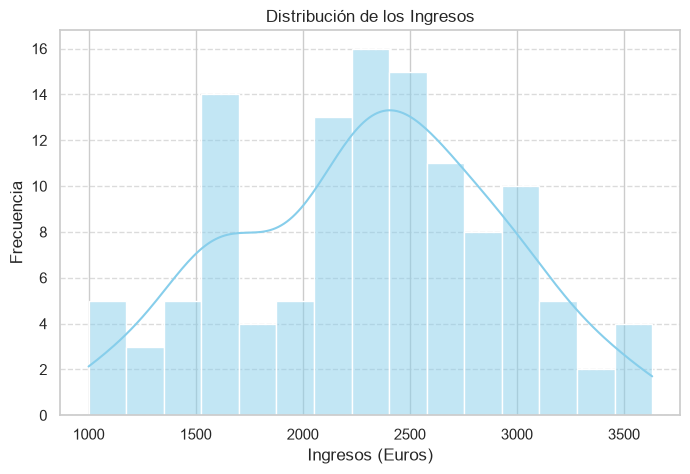

In [24]:
## Ejercicio 3

plt.figure(figsize=(8, 5))
# Se crea el histograma con una línea de densidad (kde)
sns.histplot(df['ingresos_euros'], kde=True, color='skyblue', bins=15)

plt.title('Distribución de los Ingresos')
plt.xlabel('Ingresos (Euros)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

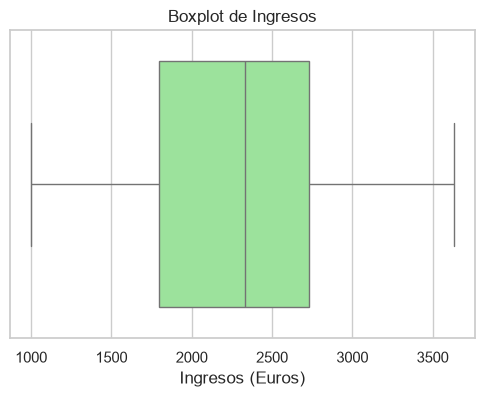

Límite superior para atípicos: 4119.625
Número de valores atípicos detectados: 0


In [25]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['ingresos_euros'], color='lightgreen')

plt.title('Boxplot de Ingresos')
plt.xlabel('Ingresos (Euros)')
plt.show()

# Código matemático para identificar los valores atípicos (Outliers)
Q1 = df['ingresos_euros'].quantile(0.25)
Q3 = df['ingresos_euros'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos = df[(df['ingresos_euros'] < limite_inferior) | (df['ingresos_euros'] > limite_superior)]
print(f"Límite superior para atípicos: {limite_superior}")
print(f"Número de valores atípicos detectados: {len(atipicos)}")
if len(atipicos) > 0:
    print("Valores atípicos:")
    print(atipicos['ingresos_euros'].values)

El coeficiente de correlación de Pearson entre altura y peso es: 0.7228


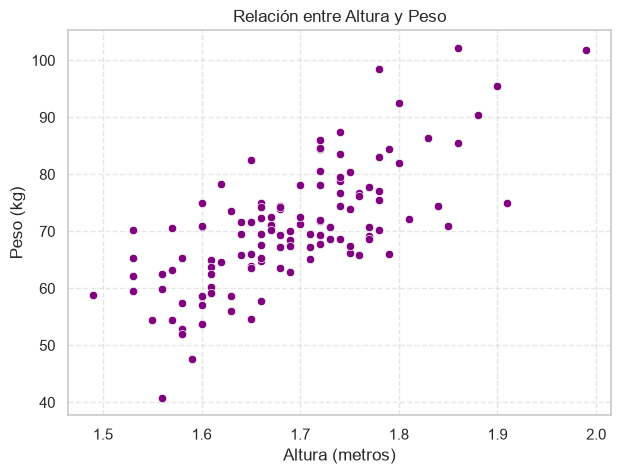

In [26]:
# Cálculo del coeficiente de correlación de Pearson
correlacion = df['altura_m'].corr(df['peso_kg'])
print(f"El coeficiente de correlación de Pearson entre altura y peso es: {correlacion:.4f}")

# Gráfico de dispersión para visualizar la relación
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='altura_m', y='peso_kg', color='purple')
plt.title('Relación entre Altura y Peso')
plt.xlabel('Altura (metros)')
plt.ylabel('Peso (kg)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\Alumno\AppData\Local\Temp\ipykernel_21468\2734112571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='actividad_fisica', y='imc', palette='Set2')


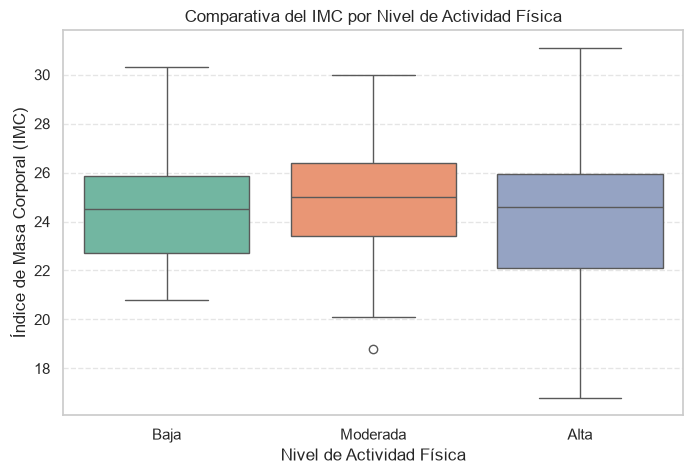

In [27]:
plt.figure(figsize=(8, 5))
# Compara la variable cuantitativa (imc) según la cualitativa (actividad_fisica)
sns.boxplot(data=df, x='actividad_fisica', y='imc', palette='Set2')

plt.title('Comparativa del IMC por Nivel de Actividad Física')
plt.xlabel('Nivel de Actividad Física')
plt.ylabel('Índice de Masa Corporal (IMC)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


--- Análisis Estadístico de la Variable: EDAD ---
Media: 42.44
Mediana: 42.50
Desviación Estándar: 13.15
Coeficiente de Asimetría: -0.19


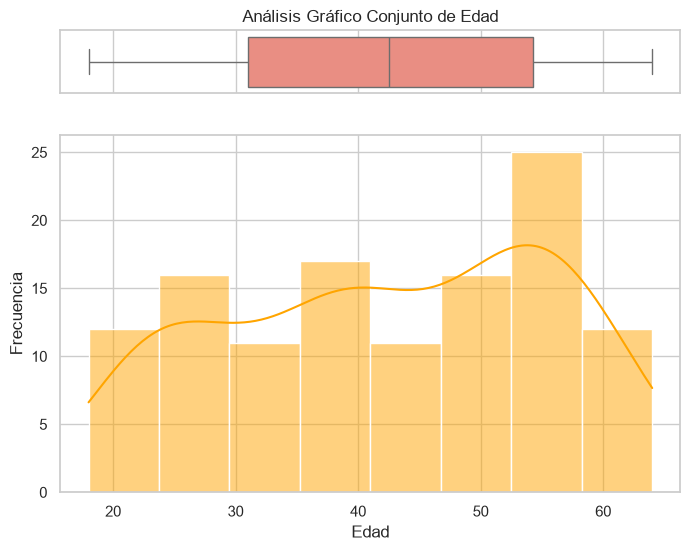

In [28]:
variable = 'edad'

# 1. Estadísticos numéricos
media = df[variable].mean()
mediana = df[variable].median()
desviacion = df[variable].std()
asimetria = df[variable].skew()

print(f"--- Análisis Estadístico de la Variable: {variable.upper()} ---")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")
print(f"Coeficiente de Asimetría: {asimetria:.2f}")

# 2. Gráficos conjuntos (Histograma + Boxplot en la misma ventana)
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(8, 6))

sns.boxplot(x=df[variable], ax=ax_box, color='salmon')
sns.histplot(x=df[variable], ax=ax_hist, kde=True, color='orange')

ax_box.set(xlabel='')
ax_box.set_title(f'Análisis Gráfico Conjunto de {variable.capitalize()}')
ax_hist.set(xlabel=variable.capitalize(), ylabel='Frecuencia')
plt.show()

C:\Users\Alumno\AppData\Local\Temp\ipykernel_21468\3446459775.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='actividad_fisica', y='imc', palette='Set2', ax=ax3)


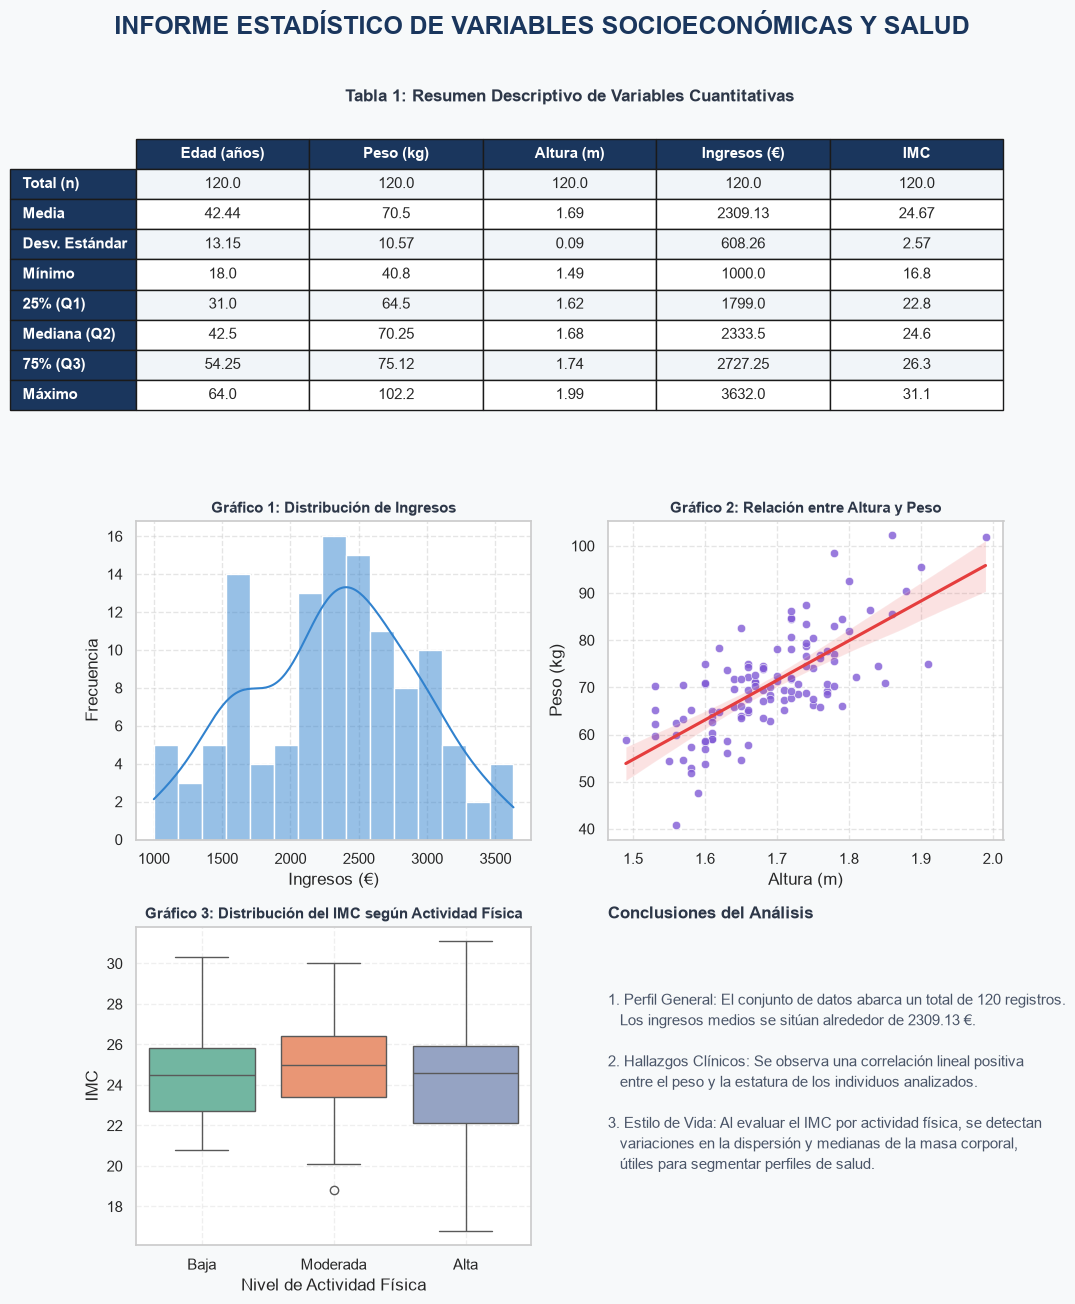

In [30]:
## Ejercicio 8
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configurar la figura para que parezca una página de informe (A4 aproximado en proporción)
fig = plt.figure(figsize=(11, 14), facecolor='#f7f9fa')
fig.suptitle('INFORME ESTADÍSTICO DE VARIABLES SOCIOECONÓMICAS Y SALUD', 
             fontsize=18, fontweight='bold', color='#1a365d', y=0.96)

# --- PANEL SUPERIOR: TABLA DESCRIPTIVA ---
ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax_table.axis('off')

# Creamos un resumen estadístico limpio de las variables principales
resumen = df[['edad', 'peso_kg', 'altura_m', 'ingresos_euros', 'imc']].describe().round(2)
resumen.index = ['Total (n)', 'Media', 'Desv. Estándar', 'Mínimo', '25% (Q1)', 'Mediana (Q2)', '75% (Q3)', 'Máximo']
resumen.columns = ['Edad (años)', 'Peso (kg)', 'Altura (m)', 'Ingresos (€)', 'IMC']

# Dibujar la tabla en el gráfico
tabla = ax_table.table(cellText=resumen.values, 
                       rowLabels=resumen.index, 
                       colLabels=resumen.columns, 
                       cellLoc='center', loc='center')

# Estilo de la tabla corregido para evitar el AttributeError
tabla.auto_set_font_size(False)
tabla.scale(1, 1.8)

# Aplicar fuente y colores celda por celda
for (row, col), cell in tabla.get_celld().items():
    cell.set_fontsize(11) # Manera correcta de aplicar el tamaño de letra
    if row == 0 or col == -1:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_facecolor('#1a365d') # Azul oscuro institucional
    else:
        cell.set_facecolor('#ffffff' if row % 2 == 0 else '#f1f5f9')

ax_table.set_title('Tabla 1: Resumen Descriptivo de Variables Cuantitativas', 
                   fontsize=12, fontweight='bold', color='#2d3748', pad=10)


# --- GRÁFICO 1: HISTOGRAMA DE INGRESOS (Centro Izquierda) ---
ax1 = plt.subplot2grid((3, 2), (1, 0))
sns.histplot(df['ingresos_euros'], kde=True, color='#3182ce', bins=15, ax=ax1)
ax1.set_title('Gráfico 1: Distribución de Ingresos', fontsize=11, fontweight='bold', color='#2d3748')
ax1.set_xlabel('Ingresos (€)')
ax1.set_ylabel('Frecuencia')
ax1.grid(True, linestyle='--', alpha=0.5)


# --- GRÁFICO 2: DISPERSIÓN ALTURA VS PESO (Centro Derecha) ---
ax2 = plt.subplot2grid((3, 2), (1, 1))
sns.scatterplot(data=df, x='altura_m', y='peso_kg', color='#805ad5', alpha=0.8, ax=ax2)
# Añadimos línea de tendencia implícita
sns.regplot(data=df, x='altura_m', y='peso_kg', scatter=False, color='#e53e3e', ax=ax2)
ax2.set_title('Gráfico 2: Relación entre Altura y Peso', fontsize=11, fontweight='bold', color='#2d3748')
ax2.set_xlabel('Altura (m)')
ax2.set_ylabel('Peso (kg)')
ax2.grid(True, linestyle='--', alpha=0.5)


# --- GRÁFICO 3: COMPARATIVA IMC POR ACTIVIDAD FÍSICA (Abajo Izquierda) ---
ax3 = plt.subplot2grid((3, 2), (2, 0))
sns.boxplot(data=df, x='actividad_fisica', y='imc', palette='Set2', ax=ax3)
ax3.set_title('Gráfico 3: Distribución del IMC según Actividad Física', fontsize=11, fontweight='bold', color='#2d3748')
ax3.set_xlabel('Nivel de Actividad Física')
ax3.set_ylabel('IMC')
ax3.grid(True, linestyle='--', alpha=0.3)


# --- TEXTO DE CONCLUSIONES (Abajo Derecha) ---
ax_text = plt.subplot2grid((3, 2), (2, 1))
ax_text.axis('off')
ax_text.set_title('Conclusiones del Análisis', fontsize=12, fontweight='bold', color='#2d3748', loc='left')

conclusiones = (
    "1. Perfil General: El conjunto de datos abarca un total de 120 registros.\n"
    f"   Los ingresos medios se sitúan alrededor de {df['ingresos_euros'].mean():.2f} €.\n\n"
    "2. Hallazgos Clínicos: Se observa una correlación lineal positiva\n"
    "   entre el peso y la estatura de los individuos analizados.\n\n"
    "3. Estilo de Vida: Al evaluar el IMC por actividad física, se detectan\n"
    "   variaciones en la dispersión y medianas de la masa corporal,\n"
    "   útiles para segmentar perfiles de salud."
)
ax_text.text(0.0, 0.8, conclusiones, fontsize=10.5, color='#4a5568', va='top', ha='left', linespacing=1.5)

# Ajustar el diseño para que no se solapen los elementos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
